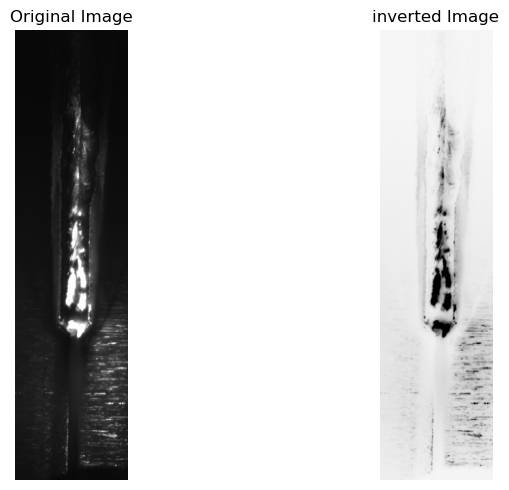

In [4]:
import cv2 as cv #OpenCV is used for image and video processing.
import numpy as np #for numerical operations
import matplotlib.pyplot as plt
img = cv.imread(cv.samples.findFile("img.tif")) #reads the image into a Numpy array
mod_img=img
if img is None:
  sys.exit("Could not read the image.") 
else:
  #mask = np.full_like(img 255)
  inverted_image = cv.bitwise_not(img) #inverts the colour of the image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray') #treats the image as gray scale
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('inverted Image')
plt.imshow(inverted_image, cmap='gray')
plt.axis('off')

plt.tight_layout() #titles and images for both images not overlap
plt.show()

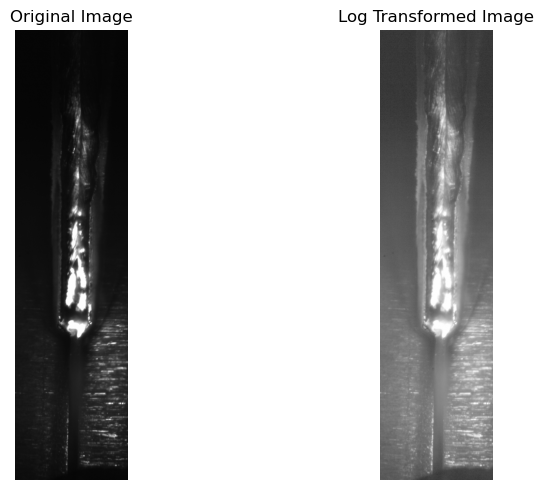

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread("img.tif", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Could not load the image.")
    exit()

# Convert to float
img_float = image.astype(np.float64)  #converts the image from unit to float and log tran. requires floats to avoid overflow

# Compute scaling constant
m = np.max(img_float)
if m == 0:
    c = 1  # avoid division by zero
else:
    c = 255 / np.log(1 + m)

# Apply log transform
log_transformed = c * np.log(1 + img_float)

# Clip and convert to uint8
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Log Transformed Image')
plt.imshow(log_transformed, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


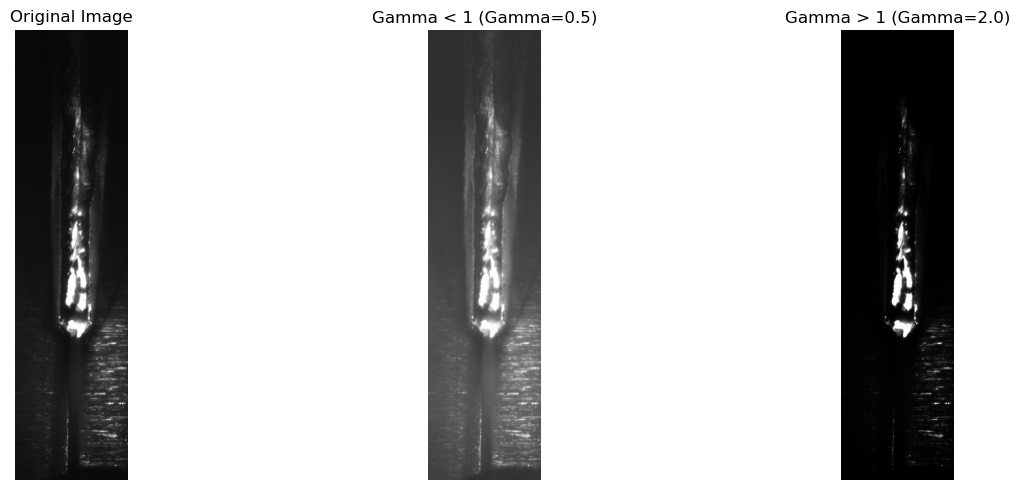

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(cv2.samples.findFile("img.tif")) 

if image is None:
    print(f"Error: Could not load the image from path '{image_path}'. Please check the file path.")
    exit()


normalized_image = image / 255.0 #converts pixels value from the range [0, 255] to [0,1]


gamma_values = [0.5, 2.0] #gamma < 1- brightens the image and gamma > 1-darkens the image
gamma_corrected_images = []  #to store the transformed images

for gamma in gamma_values:
    gamma_corrected = np.array(255 * (normalized_image ** gamma), dtype=np.uint8) #rescales the corrected image back to [0,255]
    gamma_corrected_images.append(gamma_corrected)


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

# Gamma < 1
plt.subplot(1, 3, 2)
plt.title(f'Gamma < 1 (Gamma={gamma_values[0]})') #first values in gamma values that is 0.5
plt.imshow(gamma_corrected_images[0], cmap='gray')
plt.axis('off')

# Gamma > 1
plt.subplot(1, 3, 3)
plt.title(f'Gamma > 1 (Gamma={gamma_values[1]})')
plt.imshow(gamma_corrected_images[1], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

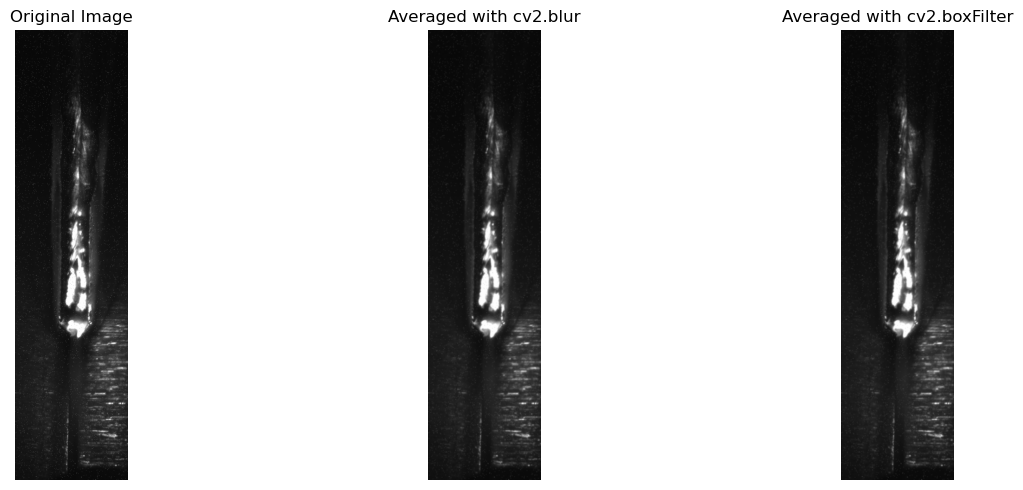

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(cv2.samples.findFile("peppersaltImg.tif"))

if image is None:
    print(f"Error: Could not load the image from path '{image_path}'. Please check the file path.")
    exit()
kernel_size = (5, 5) #A 5×5 filter means each output pixel is computed using its surrounding 25 pixels.


averaged_image_blur = cv2.blur(image, kernel_size) #blur is an opencv builtin function


averaged_image_boxfilter = cv2.boxFilter(image, ddepth=-1, ksize=kernel_size, normalize=True) #ddepth=-1 Do not change the data type. Keep the output same as input.”


plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')


plt.subplot(1, 3, 2)
plt.title('Averaged with cv2.blur')
plt.imshow(averaged_image_blur, cmap='gray')
plt.axis('off')


plt.subplot(1, 3, 3)
plt.title('Averaged with cv2.boxFilter')
plt.imshow(averaged_image_boxfilter, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

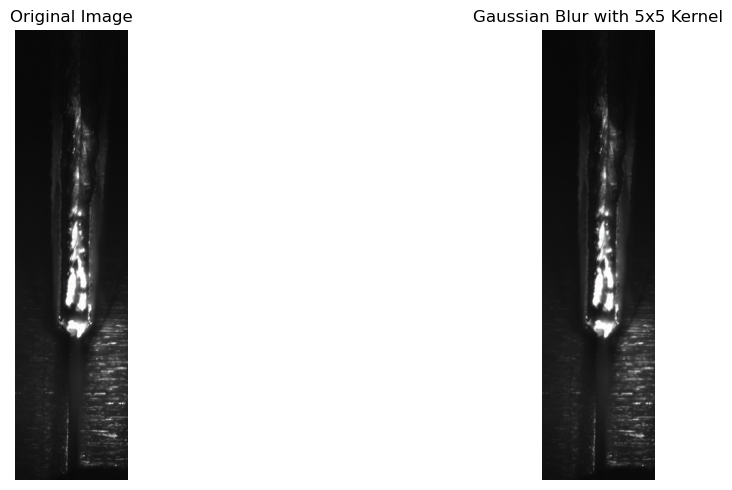

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(cv2.samples.findFile("gaussianNoiseImg.tif")) 

if image is None:
    print(f"Error: Could not load the image from path '{image_path}'. Please check the file path.")
    exit()

kernel_size_5x5 = (5, 5)   #This means the blur will consider a 5×5 pixel neighborhood.
gaussian_blurred_5x5 = cv2.GaussianBlur(image, kernel_size_5x5, sigmaX=0) #blur window size and calculates sigma(spread of gaussian curve)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')


plt.subplot(1, 2, 2)
plt.title('Gaussian Blur with 5x5 Kernel')
plt.imshow(cv2.cvtColor(gaussian_blurred_5x5, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

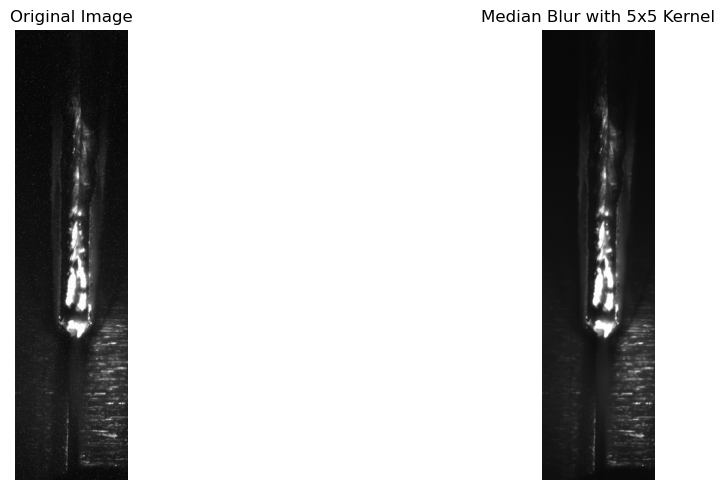

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(cv2.samples.findFile("peppersaltImg.tif")) 

if image is None:
    print(f"Error: Could not load the image from path '{image_path}'. Please check the file path.")
    exit()


median_blurred_5x5 = cv2.medianBlur(image, 5)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')


plt.subplot(1, 2, 2)
plt.title('Median Blur with 5x5 Kernel')
plt.imshow(cv2.cvtColor(median_blurred_5x5, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()